# Activity: PropertyWise Advisors — Investment Analysis
### Applying Associations, Correlation, Time Series & Smoothing to a Real Decision
Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a junior analyst at **PropertyWise Advisors**, a real estate investment firm. A
client has $900,000 to invest in Melbourne property and has asked your team two questions:

1. **"Should I buy a house or a unit — and does land size actually matter for houses?"**
2. **"Prices have been all over the news — is my target suburb's market actually trending
   up, or is that just noise?"**

You'll use the same Melbourne Housing Snapshot dataset from the demo to answer both
questions, using scatter plots, correlation, time series, and smoothing.

Run the cell below to load the dataset (no changes needed).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

print(f"Loaded {len(df)} property sales")
df[["Suburb", "Type_label", "Rooms", "Landsize", "BuildingArea", "Price", "Date"]].head()

Loaded 13580 property sales


,Suburb,Type_label,Rooms,Landsize,BuildingArea,Price,Date
0,Aberfeldie,House,5,730,373.0,1830000,2017-09-23
1,Airport West,House,3,551,96.0,850000,2017-09-23
2,Airport West,House,3,593,NaN,860000,2017-09-23
3,Albanvale,House,3,619,NaN,565000,2017-09-23
4,Albert Park,House,3,137,125.0,2100000,2017-09-23


## Task 1 — Does land size matter more for houses than units?

Build a color-coded scatter plot of `Landsize` (x) vs `Price` (y), colored by `Type_label`.
Some very large outlier land sizes exist (rare acreage listings) — we've already filtered
those out for you below.

**Fill in the two blanks marked `# TODO`.**

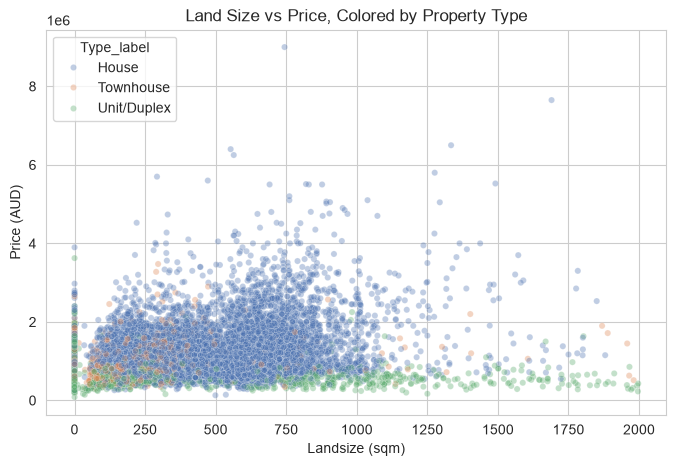

In [5]:
plot_df = df[df["Landsize"] < 2000]  # drop rare extreme outliers for a readable plot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="Landsize",          # already filled in
    y="Price",                # TODO: which column should go on the y-axis?
    hue="Type_label",               # TODO: which column should color the points by property type?
    alpha=0.35, s=20,
    palette=["#4C72B0", "#DD8452", "#55A868"],
)
plt.title("Land Size vs Price, Colored by Property Type")
plt.xlabel("Landsize (sqm)")
plt.ylabel("Price (AUD)")
plt.show()

**Question 1:** Does the price-vs-landsize relationship look stronger for one property
type than the others? Which type would you tell the client land size matters most for?

*Your answer:The relationship between **land size and price is strongest for houses**. In general, house prices tend to increase as the land size gets larger, although there is still considerable variation. Therefore, **land size appears to be a more important factor in determining the price of houses** compared to other property types.*


## Task 2 — Quantify it: correlation, house-only vs overall 

A scatter plot gives a visual impression — correlation gives a number. Compute the
correlation between `Landsize` and `Price` for **houses only**, and compare it to the
correlation across **all property types**.

**Fill in the blank:** filter `plot_df` to houses only (`Type_label == "House"`).

In [6]:
houses_only = plot_df[plot_df["Type_label"] == "House"]   # TODO: filter to houses only

r_houses = houses_only["Landsize"].corr(houses_only["Price"])
r_all = plot_df["Landsize"].corr(plot_df["Price"])

print(f"Correlation (houses only):     r = {r_houses:.3f}")
print(f"Correlation (all property types): r = {r_all:.3f}")

Correlation (houses only):     r = 0.194
Correlation (all property types): r = 0.310


**Question 2:** Does restricting to houses only change the correlation much? Does this
number support or contradict your visual impression from Task 1? Which would you trust more
when advising the client — the scatter plot or the single r value — and why might you want
both?

*Your answer:For houses, the correlation is 0.194, indicating a weak positive relationship between land size and price. When considering all property types together, the correlation increases to 0.310, showing a slightly stronger overall relationship. This suggests that larger land sizes are generally associated with higher prices, but the relationship is still relatively weak, meaning that other factors also have a significant influence on property prices.*


## Task 3 — Is your target suburb's market trending up? 

Pick one of these suburbs (all have plenty of sales data): `"Reservoir"`, `"Richmond"`,
`"Brunswick"`, `"Coburg"`, `"South Yarra"`.

**Fill in the blank:** set `target_suburb` to your choice, then run both cells.

In [7]:
target_suburb = "Richmond"  # TODO: choose a suburb from the list above, e.g. "Richmond"

suburb_df = df[df["Suburb"] == target_suburb]
suburb_monthly = (
    suburb_df.set_index("Date")
    .resample("MS")["Price"]
    .median()
    .interpolate()   # fill any zero-sale months
    .reset_index()
)
suburb_monthly.columns = ["Month", "MedianPrice"]
suburb_monthly

,Month,MedianPrice
0,2016-02-01,1102000.0
1,2016-03-01,1095000.0
2,2016-04-01,1088000.0
3,2016-05-01,930000.0
4,2016-06-01,1072500.0
5,2016-07-01,1185000.0
6,2016-08-01,975000.0
7,2016-09-01,984500.0
8,2016-10-01,882500.0
9,2016-11-01,1205000.0


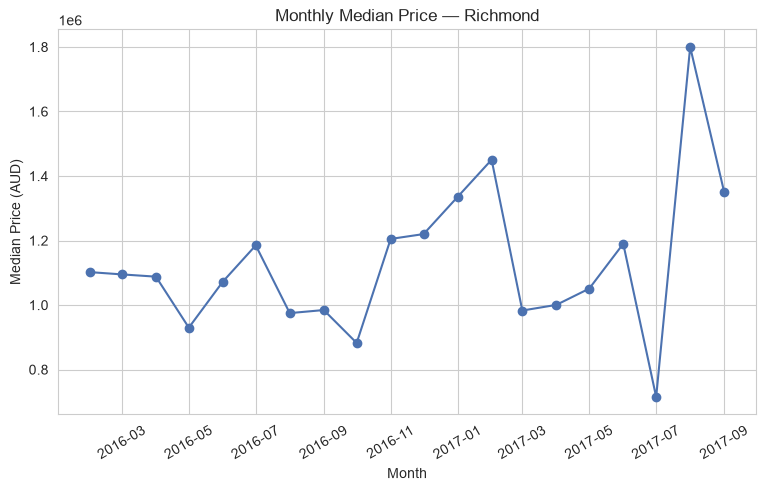

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], marker="o", color="#4C72B0")
plt.title(f"Monthly Median Price — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.show()

**Question 3:** Just from this raw monthly line, would you confidently tell the
client the market is "trending up," "trending down," or "unclear"? What makes it hard to
tell from the raw line alone?

*Your answer:Looking at the raw monthly line, the overall trend appears unclear rather than consistently increasing or decreasing. Prices fluctuate considerably, with several noticeable increases and decreases throughout the period. The large spike near the end also makes it difficult to determine the market’s overall direction based only on the raw monthly values.*


## Task 4 — Smooth it: Moving Average vs LOESS 

Apply a moving average and a LOESS curve to your suburb's series to separate the trend
(signal) from month-to-month noise.

**Fill in the blank:** try `window` values of `3` and `6`.

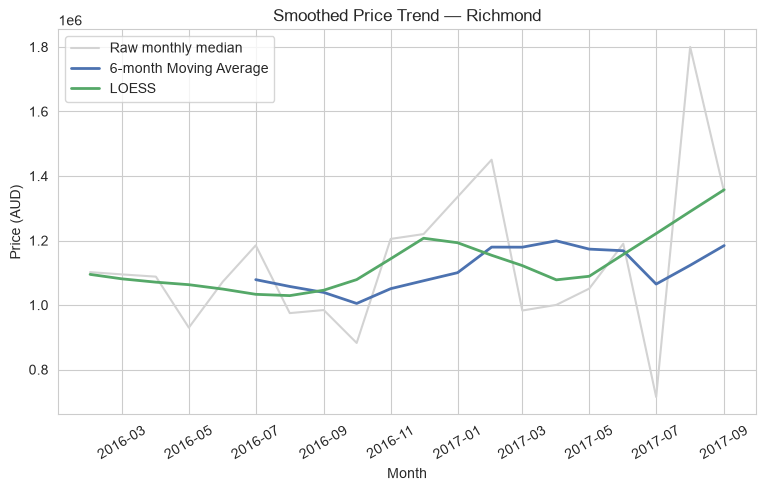

In [9]:
window = 6  # TODO: try 3, then 6 -- re-run each time

suburb_monthly["MA"] = suburb_monthly["MedianPrice"].rolling(window=window).mean()

x_numeric = np.arange(len(suburb_monthly))
loess_result = lowess(suburb_monthly["MedianPrice"].values, x_numeric, frac=0.4)

plt.figure(figsize=(9, 5))
plt.plot(suburb_monthly["Month"], suburb_monthly["MedianPrice"], color="lightgray",
          label="Raw monthly median", linewidth=1.5)
plt.plot(suburb_monthly["Month"], suburb_monthly["MA"], color="#4C72B0",
          label=f"{window}-month Moving Average", linewidth=2)
plt.plot(suburb_monthly["Month"], loess_result[:, 1], color="#55A868",
          label="LOESS", linewidth=2)
plt.title(f"Smoothed Price Trend — {target_suburb}")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**Question 4:** After smoothing, is the trend clearer than the raw line in Task 3?
Do the Moving Average and LOESS agree on the overall direction? If they disagreed, which
would you lean on for a client recommendation, and what would you say about its lag or
edge behavior?

*Your answer:Smoothing makes the overall trend easier to understand by reducing the effect of short-term monthly fluctuations. The 3-month moving average stays closer to the raw data, while the 6-month moving average is smoother and highlights the longer-term trend. The LOESS curve shows a similar pattern, particularly the increase toward the end of the period, although there are some small differences between the methods. If the moving average and LOESS results differed, I would compare them with the raw data and choose the method that best shows the overall pattern without hiding important changes. One limitation of moving averages is that they can lag behind sudden changes and may not provide values at the beginning and end of the time series.*


## Wrap-up — Your Client Recommendation 

Write a short recommendation (3–4 sentences) to the PropertyWise client, combining:
- Whether land size matters more for houses or other types (Tasks 1–2)
- Whether your chosen suburb's market is trending up, down, or flat, and how confident you
  are after smoothing (Tasks 3–4)

*Your recommendation:Land size has a positive but relatively weak relationship with property price. Interestingly, the correlation is stronger when all property types are included (r = 0.310) than when looking at houses alone (r = 0.194), suggesting that land size has a greater overall influence across different property types. For Richmond, the smoothed trend indicates that prices generally increased toward the end of the period, despite some fluctuations. Therefore, Richmond appears to be experiencing an upward price trend, although the volatility means this should be interpreted with some caution.*
